In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Adjust these paths if needed
processed_dir = "data/processed"


In [16]:
import os
import pandas as pd

processed_dir = "../data/processed"
data = {}

# List all .parquet files in processed_dir
files = [f for f in os.listdir(processed_dir) if f.endswith('.parquet')]

for file in files:
    ticker = file.replace('.parquet', '')
    file_path = os.path.join(processed_dir, file)
    try:
        df = pd.read_parquet(file_path)
        data[ticker] = df
        print(f"Loaded {ticker} with {len(df)} rows")
    except Exception as e:
        print(f"Error loading {ticker}: {e}")


Loaded AAPL with 751 rows
Loaded AGG with 751 rows
Loaded BTC-USD with 1095 rows
Loaded EURUSD with 780 rows
Loaded EURUSD=X with 781 rows
Loaded EURUSDX with 779 rows
Loaded GLD with 751 rows
Loaded IWM with 751 rows
Loaded MSFT with 751 rows
Loaded QQQ with 751 rows
Loaded SLV with 751 rows
Loaded SPY with 751 rows
Loaded spy_1d_raw with 32 rows
Loaded TLT with 751 rows
Loaded USO with 751 rows
Loaded VIX with 751 rows
Loaded XLF with 751 rows
Loaded XLV with 751 rows
Loaded ^VIX with 752 rows


In [21]:
def backtest_signal(df, price_col='Close'):
    """
    Backtests a simple long/short strategy based on the 'signal' column.
    - signal should be +1, -1, or 0
    - Returns cumulative strategy return
    """
    df = df.copy()  # avoid SettingWithCopyWarning

    # Calculate daily returns from the price column
    daily_ret = df[price_col].pct_change()

    # Generate strategy returns (signal * next day's return)
    df['strategy_ret'] = df['signal'].shift(1) * daily_ret

    # Clean up missing values
    df['strategy_ret'] = df['strategy_ret'].fillna(0)

    # Compute cumulative return
    df['cumulative_strategy_ret'] = (1 + df['strategy_ret']).cumprod()

    return df

Skipping AAPL: 'signal' column missing.
Skipping AGG: 'signal' column missing.
Skipping BTC-USD: 'signal' column missing.
Skipping EURUSD: no valid price column found.
Skipping EURUSD=X: 'signal' column missing.
Skipping EURUSDX: no valid price column found.
Skipping GLD: 'signal' column missing.
Skipping IWM: 'signal' column missing.
Skipping MSFT: 'signal' column missing.
Skipping QQQ: 'signal' column missing.
Skipping SLV: 'signal' column missing.
Skipping SPY: 'signal' column missing.
Error processing spy_1d_raw: unsupported operand type(s) for /: 'str' and 'str'
Skipping TLT: 'signal' column missing.
Skipping USO: 'signal' column missing.
Skipping VIX: no valid price column found.
Skipping XLF: 'signal' column missing.
Skipping XLV: 'signal' column missing.
Skipping ^VIX: 'signal' column missing.


C:\Users\salif\AppData\Local\Temp\ipykernel_35516\542830924.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret = df[price_col].pct_change()
C:\Users\salif\AppData\Local\Temp\ipykernel_35516\3254600839.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


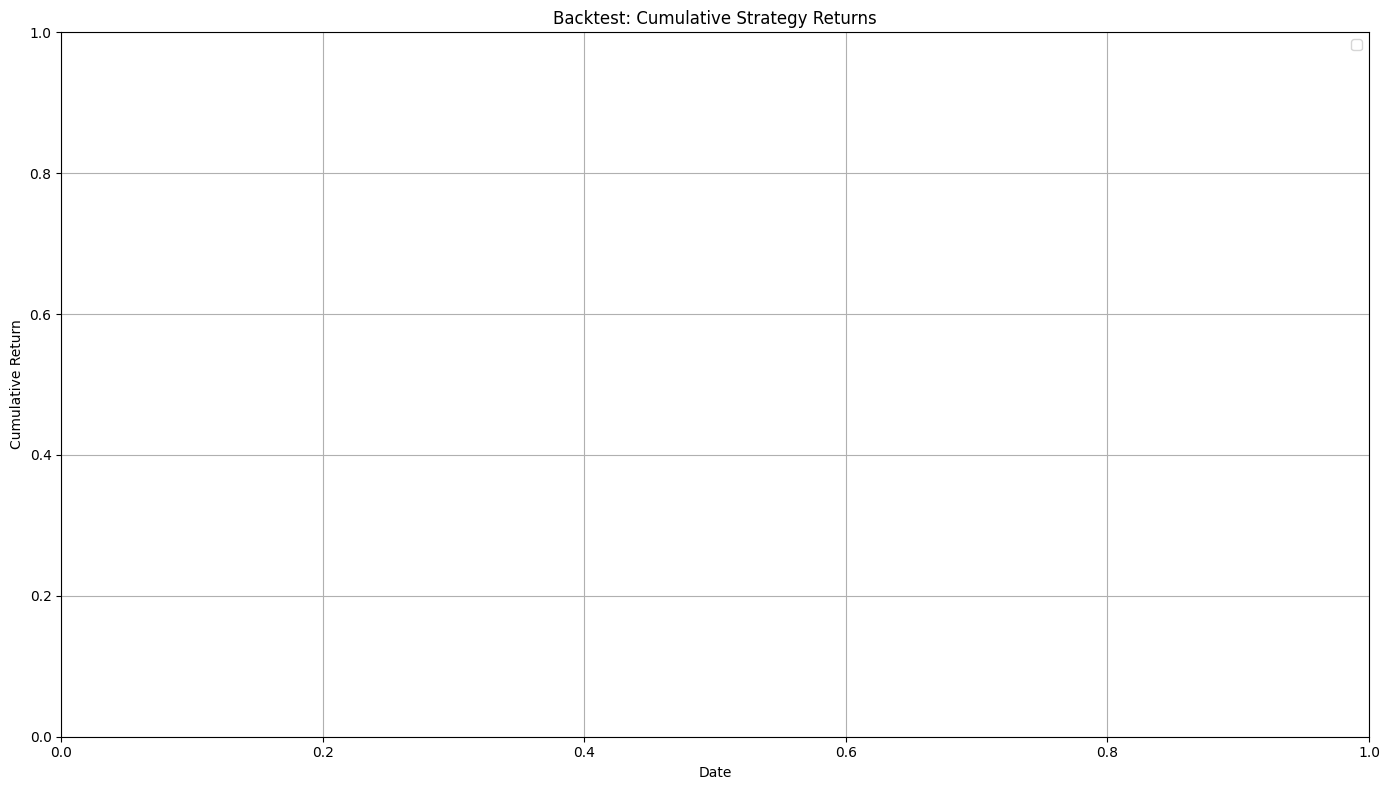

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for ticker, df in data.items():
    # Handle MultiIndex columns by flattening
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]

    # Determine price column (assumes it's Close or Close_TICKER)
    possible_cols = [f'Close_{ticker}', 'Close']
    price_col = next((col for col in possible_cols if col in df.columns), None)

    if price_col is None:
        print(f"Skipping {ticker}: no valid price column found.")
        continue

    if 'signal' not in df.columns:
        print(f"Skipping {ticker}: 'signal' column missing.")
        continue

    try:
        df_bt = backtest_signal(df, price_col)
        plt.plot(df_bt['cumulative_strategy_ret'], label=ticker)
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

plt.title("Backtest: Cumulative Strategy Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/processed'

In [19]:
for ticker, df in data.items():
    print(f"Ticker: {ticker}")
    print("Columns:")
    print(df.columns)
    
    if isinstance(df.columns, pd.MultiIndex):
        price_col = ('Close', ticker) if ('Close', ticker) in df.columns else 'Close'
    else:
        price_col = 'Close' if 'Close' in df.columns else df.columns[0]
    
    print(f"Chosen price_col: {price_col}")
    print("-" * 40)


Ticker: AAPL
Columns:
MultiIndex([(                  'Close', 'AAPL'),
            (                   'High', 'AAPL'),
            (                    'Low', 'AAPL'),
            (                   'Open', 'AAPL'),
            (                 'Volume', 'AAPL'),
            (        'Original_Ticker',     ''),
            (             '12m_return',     ''),
            (                 'signal',     ''),
            (           'strategy_ret',     ''),
            ('cumulative_strategy_ret',     '')],
           names=['Price', 'Ticker'])
Chosen price_col: ('Close', 'AAPL')
----------------------------------------
Ticker: AGG
Columns:
MultiIndex([(                  'Close', 'AGG'),
            (                   'High', 'AGG'),
            (                    'Low', 'AGG'),
            (                   'Open', 'AGG'),
            (                 'Volume', 'AGG'),
            (        'Original_Ticker',    ''),
            (             '12m_return',    ''),
            (  

In [23]:
import os
import pandas as pd

processed_dir = "../data/processed"

# Check if the processed folder exists
if not os.path.exists(processed_dir):
    print("❌ Processed folder does not exist. Did you run 02_generate_signals.ipynb?")
else:
    files = [f for f in os.listdir(processed_dir) if f.endswith('.parquet')]
    
    if not files:
        print("⚠️ No processed .parquet files found.")
    else:
        print(f"✅ Found {len(files)} processed files:")
        for f in files:
            file_path = os.path.join(processed_dir, f)
            try:
                df = pd.read_parquet(file_path)
                signal_check = 'signal' in df.columns or any(
                    'signal' in str(col) for col in df.columns
                )
                close_check = 'Close' in df.columns or any(
                    'Close' in str(col) for col in df.columns
                )
                print(f"✔ {f}: Rows={len(df)}, Signal={'✅' if signal_check else '❌'}, Close={'✅' if close_check else '❌'}")
            except Exception as e:
                print(f"❌ {f}: Error reading file → {e}")


✅ Found 19 processed files:
✔ AAPL.parquet: Rows=751, Signal=✅, Close=✅
✔ AGG.parquet: Rows=751, Signal=✅, Close=✅
✔ BTC-USD.parquet: Rows=1095, Signal=✅, Close=✅
✔ EURUSD.parquet: Rows=780, Signal=✅, Close=✅
✔ EURUSD=X.parquet: Rows=781, Signal=✅, Close=✅
✔ EURUSDX.parquet: Rows=779, Signal=✅, Close=✅
✔ GLD.parquet: Rows=751, Signal=✅, Close=✅
✔ IWM.parquet: Rows=751, Signal=✅, Close=✅
✔ MSFT.parquet: Rows=751, Signal=✅, Close=✅
✔ QQQ.parquet: Rows=751, Signal=✅, Close=✅
✔ SLV.parquet: Rows=751, Signal=✅, Close=✅
✔ SPY.parquet: Rows=751, Signal=✅, Close=✅
✔ spy_1d_raw.parquet: Rows=32, Signal=✅, Close=✅
✔ TLT.parquet: Rows=751, Signal=✅, Close=✅
✔ USO.parquet: Rows=751, Signal=✅, Close=✅
✔ VIX.parquet: Rows=751, Signal=✅, Close=✅
✔ XLF.parquet: Rows=751, Signal=✅, Close=✅
✔ XLV.parquet: Rows=751, Signal=✅, Close=✅
✔ ^VIX.parquet: Rows=752, Signal=✅, Close=✅
